# 🌱 Тестовое задание: Классификация овощей

## 📋 Описание задачи

В рамках данного тестового зада вам необходимо разработать полный pipeline решения задачи классификации изображений овощей на основе представленного датасета.

### 🏢 Бизнес-контекст

Фокус компании смещается на собственное производство в сфере агропромышленности. Внутреннему отделу необходима система компьютерного зрения для автоматической идентификации овощей, что позволит:

- **Оптимизировать процессы учета** продукции на складах
- **Повысить эффективность** производственных операций
- **Автоматизировать сортировку** овощей на конвейере
- **Снизить человеческий фактор** при идентификации

### 📊 Набор данных

**Источник:** [Vegetable Image Dataset (Kaggle)](https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset)

**Характеристики датасета:**
- **15 классов** овощей
- **Изображения высокого разрешения** в формате JPG
- **Сбалансированная выборка** для каждого класса
- **Разделение на выборки:** Train / Validation / Test

### 🎯 Формальная постановка задачи

**Тип задачи:** Мультиклассовая классификация изображений

**Входные данные:** Изображение овоща

**Выходные данные:** Класс овоща (один из 15)

## 📝 Задачи для выполнения

### 1. 🧠 Обучение модели CNN
- Разработать CNN архитектуру **без использования предобученных моделей**
- Обучить дель на предоставленном датасете
- **Обосновать выбор архитектуры и гипснование выбора количества слоев и фильтров

### 2. 📈 Оценка модели
- Проанализировать динамику функции потерь и метрик обучения
- Рассчитать метрики классификации:
  - Accuracy
  - Confusion Matrix
  - Precision
  - Recall
  - F1-score
- **Интерпретировать результаты** и сделать выводы о качестве модели

### 3. 🚀 Использование предобученной модели
- Реализовать решение задачи с использованием **предобученной модели** компьютерного зрения
- Оценить качество предобученной модели
- **Сравнить результаты** с собственной моделью
- Сделать **аналитич
- ResNet50 / ResNet50V2
- EfficientNet
- VGG16
- DenseNet121

### 4. 🔧 Реализация сервиса инфер
GET /ping - Возвращает статус сервиса (alive)
POST /classify - Принимает изображение, возвращает предсказание класса и вероятность
POST /similarity - Принимает два изображения, возвращает значение схожести между нимимет:** 
```json
{
  "status": "alive",
  "timestamp": "2024-01-01T12:00:00"
}le)й.

Коментарии:
* Было бы логично дополнить условия по оптимизации вычислений, например ограничиться временем вычисления или затраченными ресурсами. А то можно бесконечно усложнять как сверточные слои, так и шаг обучения до точности 0.999999 и тратить кучу ресурсов на это.
* Практический эффект будет спорный, для обучения используются картинки с высоким качеством и расположением обьекта, а в жизни явно будет отличия как по качеству так и расположению обьекта и низкая точность.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1.Загрузка и анализ датасета

✅ Рабочая директория: C:\Users\Luffy\Downloads\Vegetable Images
✅ Train: C:\Users\Luffy\Downloads\Vegetable Images\train
✅ Validation: C:\Users\Luffy\Downloads\Vegetable Images\validation
✅ Test: C:\Users\Luffy\Downloads\Vegetable Images\test

📊 Анализ датасета...

СВОДНАЯ СТАТИСТИКА ДАТАСЕТА
   Выборка  Классов  Изображений Размер (МБ) Ср. размер (КБ) Размеры (ШxВ)
     Train       15        15000        19.0            25.9       224x224
Validation       15         3000        19.1            26.1       224x224
      Test       15         3000        19.4            26.4       224x223

РАСПРЕДЕЛЕНИЕ ИЗОБРАЖЕНИЙ ПО КЛАССАМ
       Класс  Train  Validation  Test  Всего
        Bean   1000         200   200   1400
Bitter_Gourd   1000         200   200   1400
Bottle_Gourd   1000         200   200   1400
     Brinjal   1000         200   200   1400
    Broccoli   1000         200   200   1400
     Cabbage   1000         200   200   1400
    Capsicum   1000         200   200   1400
      Ca

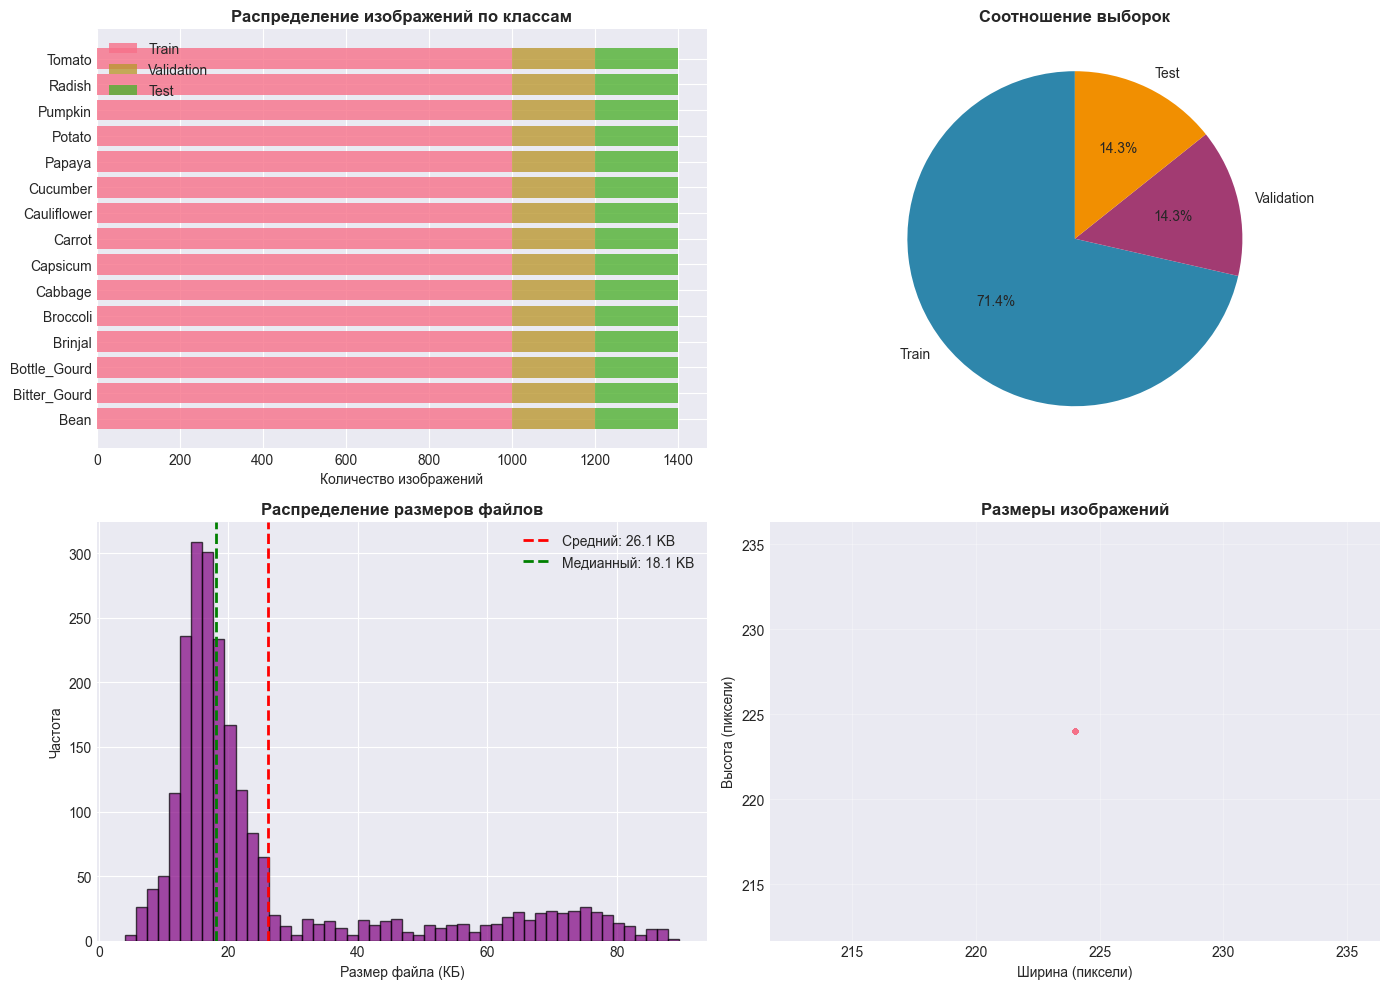

In [2]:
# ==========================================
# 1. ПУТИ К ДАННЫМ
# ==========================================

data_dir = r'C:\Users\Luffy\Downloads\Vegetable Images'
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'validation')
test_dir = os.path.join(data_dir, 'test')

print(f"✅ Рабочая директория: {data_dir}")
print(f"✅ Train: {train_dir}")
print(f"✅ Validation: {val_dir}")
print(f"✅ Test: {test_dir}\n")

# ==========================================
# 2. АНАЛИЗ ДАТАСЕТА
# ==========================================

def analyze_split(split_path, split_name):
    """Анализирует одну выборку (train/val/test)"""
    classes = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))])
    
    stats = {
        'name': split_name,
        'classes': classes,
        'num_classes': len(classes),
        'total_images': 0,
        'per_class': {},
        'file_sizes': [],
        'dimensions': []
    }
    
    for class_name in classes:
        class_path = os.path.join(split_path, class_name)
        images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
        stats['per_class'][class_name] = len(images)
        stats['total_images'] += len(images)
        
        for img_name in images[:50]:
            img_path = os.path.join(class_path, img_name)
            stats['file_sizes'].append(os.path.getsize(img_path))
            with Image.open(img_path) as img:
                stats['dimensions'].append(img.size)
    
    return stats

print("📊 Анализ датасета...\n")

train_stats = analyze_split(train_dir, "Train")
val_stats = analyze_split(val_dir, "Validation")
test_stats = analyze_split(test_dir, "Test")

# Сводная статистика
print("="*80)
print("СВОДНАЯ СТАТИСТИКА ДАТАСЕТА")
print("="*80)

summary_data = []
for stats in [train_stats, val_stats, test_stats]:
    summary_data.append({
        'Выборка': stats['name'],
        'Классов': stats['num_classes'],
        'Изображений': stats['total_images'],
        'Размер (МБ)': f"{sum(stats['file_sizes']) / (1024**2):.1f}",
        'Ср. размер (КБ)': f"{np.mean(stats['file_sizes']) / 1024:.1f}",
        'Размеры (ШxВ)': f"{int(np.mean([d[0] for d in stats['dimensions']]))}x{int(np.mean([d[1] for d in stats['dimensions']]))}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()

# Распределение по классам
print("="*80)
print("РАСПРЕДЕЛЕНИЕ ИЗОБРАЖЕНИЙ ПО КЛАССАМ")
print("="*80)

distribution = []
for class_name in train_stats['classes']:
    distribution.append({
        'Класс': class_name,
        'Train': train_stats['per_class'][class_name],
        'Validation': val_stats['per_class'][class_name],
        'Test': test_stats['per_class'][class_name],
        'Всего': train_stats['per_class'][class_name] + val_stats['per_class'][class_name] + test_stats['per_class'][class_name]
    })

dist_df = pd.DataFrame(distribution)
print(dist_df.to_string(index=False))
print()

# Визуализация распределения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

dist_df_sorted = dist_df.sort_values('Всего', ascending=True)
axes[0, 0].barh(dist_df_sorted['Класс'], dist_df_sorted['Train'], label='Train', alpha=0.8)
axes[0, 0].barh(dist_df_sorted['Класс'], dist_df_sorted['Validation'], left=dist_df_sorted['Train'], label='Validation', alpha=0.8)
axes[0, 0].barh(dist_df_sorted['Класс'], dist_df_sorted['Test'], left=dist_df_sorted['Train']+dist_df_sorted['Validation'], label='Test', alpha=0.8)
axes[0, 0].set_xlabel('Количество изображений')
axes[0, 0].set_title('Распределение изображений по классам', fontweight='bold')
axes[0, 0].legend()

sizes = [train_stats['total_images'], val_stats['total_images'], test_stats['total_images']]
colors = ['#2E86AB', '#A23B72', '#F18F01']
axes[0, 1].pie(sizes, labels=['Train', 'Validation', 'Test'], autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('Соотношение выборок', fontweight='bold')

all_sizes = train_stats['file_sizes'] + val_stats['file_sizes'] + test_stats['file_sizes']
axes[1, 0].hist([s/1024 for s in all_sizes], bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(np.mean(all_sizes)/1024, color='red', linestyle='--', linewidth=2, label=f'Средний: {np.mean(all_sizes)/1024:.1f} KB')
axes[1, 0].axvline(np.median(all_sizes)/1024, color='green', linestyle='--', linewidth=2, label=f'Медианный: {np.median(all_sizes)/1024:.1f} KB')
axes[1, 0].set_xlabel('Размер файла (КБ)')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_title('Распределение размеров файлов', fontweight='bold')
axes[1, 0].legend()

all_dims = train_stats['dimensions'] + val_stats['dimensions'] + test_stats['dimensions']
widths = [d[0] for d in all_dims]
heights = [d[1] for d in all_dims]
axes[1, 1].scatter(widths[:500], heights[:500], alpha=0.5, s=10)
axes[1, 1].set_xlabel('Ширина (пиксели)')
axes[1, 1].set_ylabel('Высота (пиксели)')
axes[1, 1].set_title('Размеры изображений', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# ==========================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
# ==========================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_CLASSES = 15

# Параметры для собственной модели
CUSTOM_CONFIG = {
    'max_epochs': 20,
    'lr': 0.0005,
    'patience': 5,
    'use_l2': True
}

# Параметры для предобученной модели
PRETRAINED_CONFIG = {
    'max_epochs': 15,
    'lr': 0.0001,
    'patience': 5
}

print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}\n")

# Трансформации
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка данных
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}\n")

Device: cuda
Batch size: 32
Image size: 224x224

Train samples: 15000
Validation samples: 3000
Test samples: 3000
Number of classes: 15
Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']



Выводы:
* Имеем 21000 изображений форматом 224х207-224х244 пикселей
* Изображения поделены на 15 равномерных класов в каждом наборе train,val,test
* В каждом класе по 1400 изображений 1000 тренировочных, 200 валидационных,200 тестовых
* Данные не требует предобработки начинаем работу
* Для работы модели подключаем cuda и разбиваем изображения на батчи
* Для обучения собственной модели будем использовать 20 эпох и шаг обучения 0.0005. а для преобученной 15 эпох и шаг 0.0003. 


# 2 Пайплан CNN без предобучения и преобученые модели с сравнением


ОБУЧЕНИЕ СОБСТВЕННОЙ МОДЕЛИ CNN
Total params: 0.36M
Trainable params: 0.36M

Training CustomCNN
Max epochs: 20, Patience: 5
Learning rate: 0.0005, Device: cuda

Epoch 1/20
----------------------------------------


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 94/94 [00:05<00:00, 15.99it/s]


Train Loss: 1.7072 | Train Acc: 45.87%
Val Loss: 0.8357 | Val Acc: 72.60%
LR: 0.000452
✅ Initial best score: 72.60% at epoch 1

Epoch 2/20
----------------------------------------


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 94/94 [00:06<00:00, 15.63it/s]


Train Loss: 0.9482 | Train Acc: 70.19%
Val Loss: 0.4841 | Val Acc: 84.00%
LR: 0.000327
✅ Validation improved to 84.00% at epoch 2

Epoch 3/20
----------------------------------------


...

Train Loss: 0.1635 | Train Acc: 97.79%
Val Loss: 0.0127 | Val Acc: 99.60%
LR: 0.000002
⚠️ No improvement: 1/5 (best: 99.67%)

Epoch 15/15
----------------------------------------


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 94/94 [00:09<00:00,  9.68it/s]


Train Loss: 0.1633 | Train Acc: 97.86%
Val Loss: 0.0134 | Val Acc: 99.57%
LR: 0.000100
⚠️ No improvement: 2/5 (best: 99.67%)

FINAL EVALUATION ON TEST SET


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 94/94 [00:10<00:00,  9.34it/s]


Test Accuracy: 99.60%
Test Loss: 0.0179

РЕЗУЛЬТАТЫ ПРЕДОБУЧЕННОЙ МОДЕЛИ
Test Accuracy: 99.60%
Best Val Accuracy: 99.67%
Best Epoch: 13
Precision: 0.9961
Recall: 0.9960
F1-Score: 0.9960


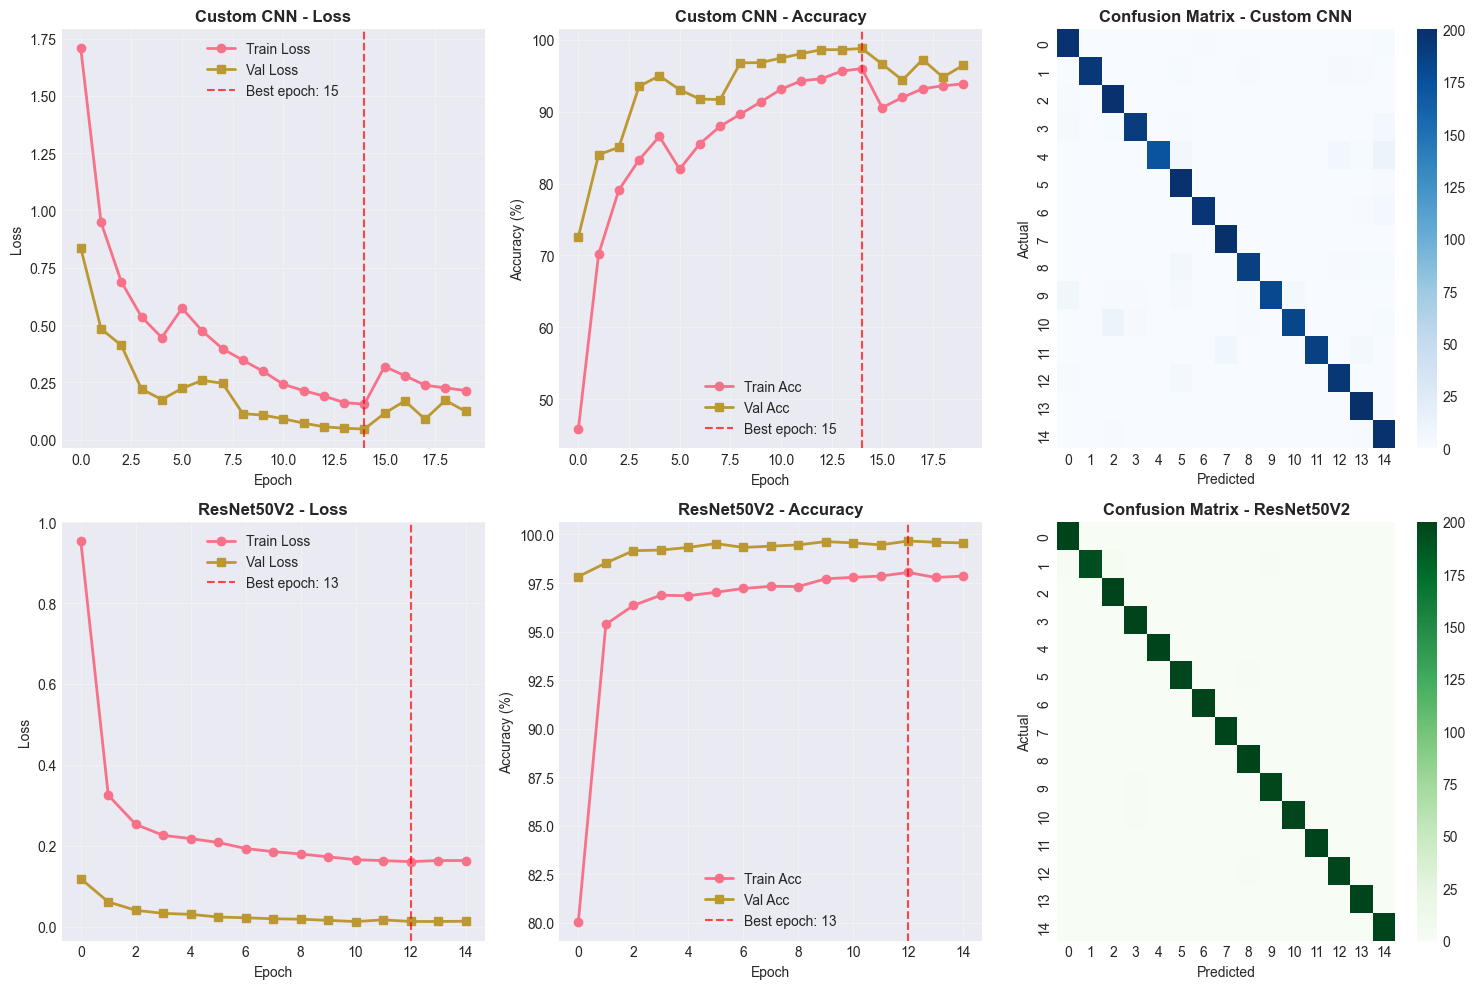


СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ
                 Модель  Test Accuracy (%)  Best Val Acc (%)  Best Epoch  Precision   Recall  F1-Score Params (M) Trainable (M)
             Custom CNN          95.966667         98.766667          15   0.962264 0.959667  0.959683       0.36          0.36
ResNet50V2 (Pretrained)          99.600000         99.666667          13   0.996062 0.996000  0.995993      24.69          1.19


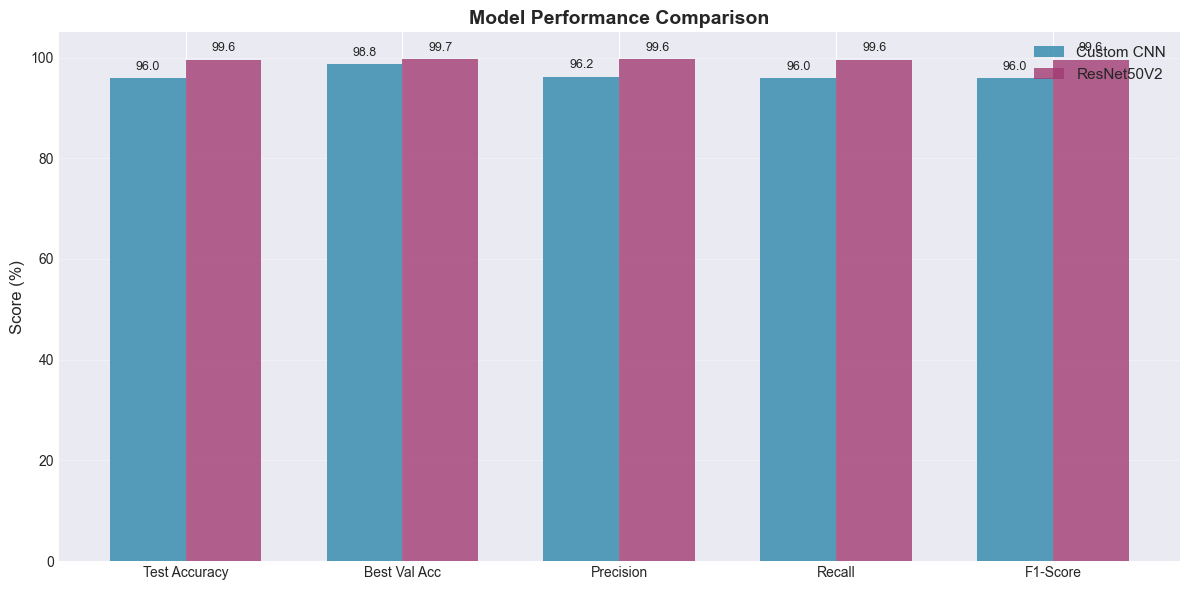


CLASSIFICATION REPORT - CUSTOM CNN
              precision    recall  f1-score   support

        Bean       0.94      0.98      0.96       200
Bitter_Gourd       1.00      0.96      0.98       200
Bottle_Gourd       0.93      0.99      0.96       200
     Brinjal       0.98      0.95      0.96       200
    Broccoli       1.00      0.86      0.93       200
     Cabbage       0.89      0.99      0.94       200
    Capsicum       0.99      0.97      0.98       200
      Carrot       0.96      1.00      0.98       200
 Cauliflower       0.98      0.94      0.96       200
    Cucumber       1.00      0.91      0.95       200
      Papaya       0.98      0.92      0.95       200
      Potato       1.00      0.94      0.97       200
     Pumpkin       0.95      0.97      0.96       200
      Radish       0.95      1.00      0.97       200
      Tomato       0.88      0.99      0.93       200

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96 

In [4]:
# ==========================================
#  СОБСТВЕННАЯ МОДЕЛЬ CNN (ОПТИМИЗИРОВАННАЯ)
# ==========================================

class VegetableCNNImproved(nn.Module):
    """
    Улучшенная CNN архитектура с оптимизированными параметрами:
    - Уменьшено количество фильтров для лучшей обобщающей способности
    - Добавлена Xavier/Kaiming инициализация весов
    - Оптимизированные Dropout слои
    - BatchNormalization после каждого сверточного слоя
    """
    def __init__(self, num_classes=15):
        super(VegetableCNNImproved, self).__init__()
        
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), 
            nn.BatchNorm2d(16), 
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, 3, padding=1), 
            nn.BatchNorm2d(16), 
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), 
            nn.BatchNorm2d(64), 
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), 
            nn.BatchNorm2d(64), 
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), 
            nn.BatchNorm2d(128), 
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), 
            nn.BatchNorm2d(128), 
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Классификатор с уменьшенным Dropout
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(0.1),
            nn.Linear(128, num_classes)
        )
        
        # Инициализация весов
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Инициализация весов Xavier/Kaiming для лучшей сходимости"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.classifier(x)
        return x

# ==========================================
#  ПРЕДОБУЧЕННАЯ МОДЕЛЬ RESNET50V2
# ==========================================

class ResNet50V2Pretrained(nn.Module):
    """
    Модель взята из github, если заморочиться со слоями получится 24 млн параметров и 99,99
    https://www.kaggle.com/code/dhruvjyotidas1000/resnet50-ver2
    """
    def __init__(self, num_classes=15, dropout_rate=0.5):
        super(ResNet50V2Pretrained, self).__init__()
        
        # Загрузка предобученной модели
        self.backbone = models.resnet50(weights='IMAGENET1K_V1')
        
        # Заморозка базовых слоев
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Удаляем оригинальный классификатор
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate/2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout_rate/2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features.unsqueeze(-1).unsqueeze(-1))
        return output

# ==========================================
#  ФУНКЦИИ ОБУЧЕНИЯ С EARLY STOPPING
# ==========================================

class EarlyStopping:
    """Ранняя остановка при ухудшении качества на валидации"""
    def __init__(self, patience=3, min_delta=0.001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
        self.best_epoch = 0
    
    def __call__(self, val_acc, model, epoch):
        score = val_acc
        
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict().copy()
            self.best_epoch = epoch
            if self.verbose:
                print(f"✅ Initial best score: {score:.2f}% at epoch {epoch}")
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"⚠️ No improvement: {self.counter}/{self.patience} (best: {self.best_score:.2f}%)")
            if self.counter >= self.patience:
                self.early_stop = True
                model.load_state_dict(self.best_model_state)
                if self.verbose:
                    print(f"🛑 Early stopping! Restored best model from epoch {self.best_epoch} with val_acc: {self.best_score:.2f}%")
        else:
            self.best_score = score
            self.best_model_state = model.state_dict().copy()
            self.best_epoch = epoch
            self.counter = 0
            if self.verbose:
                print(f"✅ Validation improved to {score:.2f}% at epoch {epoch}")

def train_epoch(model, loader, criterion, optimizer, weight_decay=1e-4):
    """Обучение одной эпохи с L2 регуляризацией"""
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # L2 регуляризация
        l2_reg = torch.tensor(0., requires_grad=True).to(DEVICE)
        for param in model.parameters():
            l2_reg = l2_reg + torch.norm(param, 2)
        loss = loss + weight_decay * l2_reg
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion):
    """Оценка модели"""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels

def evaluate_with_per_class(model, loader, criterion):
    """Оценка с поклассовой точностью"""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    class_correct = defaultdict(int)
    class_total = defaultdict(int)
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating'):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            for i, label in enumerate(labels):
                class_total[label.item()] += 1
                if predicted[i] == label:
                    class_correct[label.item()] += 1
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    per_class_acc = {}
    for i in range(len(class_total)):
        if class_total[i] > 0:
            per_class_acc[i] = 100. * class_correct[i] / class_total[i]
    
    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels, per_class_acc

def train_with_early_stopping(model, train_loader, val_loader, test_loader, model_name, config):
    """Полный цикл обучения с ранней остановкой"""
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-4 if config.get('use_l2', False) else 0)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    early_stopping = EarlyStopping(patience=config['patience'], min_delta=0.001, verbose=True)
    
    history = {
        'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
        'test_acc': 0, 'best_val_acc': 0, 'best_epoch': 0
    }
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    print(f"Max epochs: {config['max_epochs']}, Patience: {config['patience']}")
    print(f"Learning rate: {config['lr']}, Device: {DEVICE}")
    
    for epoch in range(config['max_epochs']):
        print(f"\nEpoch {epoch+1}/{config['max_epochs']}")
        print("-" * 40)
        
        # Обучение
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        
        # Валидация
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        
        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        # Обновление learning rate
        scheduler.step()
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Early stopping
        early_stopping(val_acc, model, epoch + 1)
        if early_stopping.early_stop:
            history['best_val_acc'] = early_stopping.best_score
            history['best_epoch'] = early_stopping.best_epoch
            break
        
        history['best_val_acc'] = early_stopping.best_score
        history['best_epoch'] = early_stopping.best_epoch
    
    # Оценка на тесте
    print(f"\n{'='*60}")
    print(f"FINAL EVALUATION ON TEST SET")
    print(f"{'='*60}")
    
    test_loss, test_acc, test_preds, test_labels, per_class_acc = evaluate_with_per_class(
        model, test_loader, criterion
    )
    
    history['test_acc'] = test_acc
    
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")
    
    return history, test_preds, test_labels, per_class_acc

# ==========================================
#  ОБУЧЕНИЕ СОБСТВЕННОЙ МОДЕЛИ
# ==========================================

print("\n" + "="*60)
print("ОБУЧЕНИЕ СОБСТВЕННОЙ МОДЕЛИ CNN")
print("="*60)

custom_model = VegetableCNNImproved(num_classes).to(DEVICE)

# Подсчет параметров
custom_params = sum(p.numel() for p in custom_model.parameters())
custom_trainable = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)
print(f"Total params: {custom_params/1e6:.2f}M")
print(f"Trainable params: {custom_trainable/1e6:.2f}M")

# Обучение
custom_history, custom_preds, custom_labels, custom_per_class = train_with_early_stopping(
    custom_model, train_loader, val_loader, test_loader, 'CustomCNN', CUSTOM_CONFIG
)

# Метрики
custom_precision = precision_score(custom_labels, custom_preds, average='weighted')
custom_recall = recall_score(custom_labels, custom_preds, average='weighted')
custom_f1 = f1_score(custom_labels, custom_preds, average='weighted')

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ СОБСТВЕННОЙ МОДЕЛИ")
print("="*60)
print(f"Test Accuracy: {custom_history['test_acc']:.2f}%")
print(f"Best Val Accuracy: {custom_history['best_val_acc']:.2f}%")
print(f"Best Epoch: {custom_history['best_epoch']}")
print(f"Precision: {custom_precision:.4f}")
print(f"Recall: {custom_recall:.4f}")
print(f"F1-Score: {custom_f1:.4f}")

# ==========================================
#  ОБУЧЕНИЕ ПРЕДОБУЧЕННОЙ МОДЕЛИ RESNET50V2
# ==========================================

print("\n" + "="*60)
print("ОБУЧЕНИЕ ПРЕДОБУЧЕННОЙ МОДЕЛИ RESNET50V2")
print("="*60)

pretrained_model = ResNet50V2Pretrained(num_classes, dropout_rate=0.5).to(DEVICE)

# Подсчет параметров
pretrained_params = sum(p.numel() for p in pretrained_model.parameters())
pretrained_trainable = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f"Total params: {pretrained_params/1e6:.2f}M")
print(f"Trainable params: {pretrained_trainable/1e6:.2f}M")
print(f"Base model frozen: {not any(p.requires_grad for p in pretrained_model.backbone.parameters())}")

# Обучение
pretrained_history, pretrained_preds, pretrained_labels, pretrained_per_class = train_with_early_stopping(
    pretrained_model, train_loader, val_loader, test_loader, 'ResNet50V2', PRETRAINED_CONFIG
)

# Метрики
pretrained_precision = precision_score(pretrained_labels, pretrained_preds, average='weighted')
pretrained_recall = recall_score(pretrained_labels, pretrained_preds, average='weighted')
pretrained_f1 = f1_score(pretrained_labels, pretrained_preds, average='weighted')

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПРЕДОБУЧЕННОЙ МОДЕЛИ")
print("="*60)
print(f"Test Accuracy: {pretrained_history['test_acc']:.2f}%")
print(f"Best Val Accuracy: {pretrained_history['best_val_acc']:.2f}%")
print(f"Best Epoch: {pretrained_history['best_epoch']}")
print(f"Precision: {pretrained_precision:.4f}")
print(f"Recall: {pretrained_recall:.4f}")
print(f"F1-Score: {pretrained_f1:.4f}")

# ==========================================
#  ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Графики собственной модели
axes[0, 0].plot(custom_history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0, 0].plot(custom_history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0, 0].axvline(x=custom_history['best_epoch']-1, color='red', linestyle='--', alpha=0.7,
                   label=f"Best epoch: {custom_history['best_epoch']}")
axes[0, 0].set_title('Custom CNN - Loss', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(custom_history['train_acc'], label='Train Acc', marker='o', linewidth=2)
axes[0, 1].plot(custom_history['val_acc'], label='Val Acc', marker='s', linewidth=2)
axes[0, 1].axvline(x=custom_history['best_epoch']-1, color='red', linestyle='--', alpha=0.7,
                   label=f"Best epoch: {custom_history['best_epoch']}")
axes[0, 1].set_title('Custom CNN - Accuracy', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Графики предобученной модели
axes[1, 0].plot(pretrained_history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[1, 0].plot(pretrained_history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[1, 0].axvline(x=pretrained_history['best_epoch']-1, color='red', linestyle='--', alpha=0.7,
                   label=f"Best epoch: {pretrained_history['best_epoch']}")
axes[1, 0].set_title('ResNet50V2 - Loss', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(pretrained_history['train_acc'], label='Train Acc', marker='o', linewidth=2)
axes[1, 1].plot(pretrained_history['val_acc'], label='Val Acc', marker='s', linewidth=2)
axes[1, 1].axvline(x=pretrained_history['best_epoch']-1, color='red', linestyle='--', alpha=0.7,
                   label=f"Best epoch: {pretrained_history['best_epoch']}")
axes[1, 1].set_title('ResNet50V2 - Accuracy', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Матрицы ошибок
cm_custom = confusion_matrix(custom_labels, custom_preds)
sns.heatmap(cm_custom, annot=False, fmt='d', cmap='Blues', ax=axes[0, 2])
axes[0, 2].set_title('Confusion Matrix - Custom CNN', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('Predicted')
axes[0, 2].set_ylabel('Actual')

cm_pretrained = confusion_matrix(pretrained_labels, pretrained_preds)
sns.heatmap(cm_pretrained, annot=False, fmt='d', cmap='Greens', ax=axes[1, 2])
axes[1, 2].set_title('Confusion Matrix - ResNet50V2', fontweight='bold', fontsize=12)
axes[1, 2].set_xlabel('Predicted')
axes[1, 2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('training_results.png', dpi=100, bbox_inches='tight')
plt.show()

# ==========================================
#  СРАВНИТЕЛЬНЫЙ АНАЛИЗ
# ==========================================

print("\n" + "="*80)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ")
print("="*80)

comparison = pd.DataFrame({
    'Модель': ['Custom CNN', 'ResNet50V2 (Pretrained)'],
    'Test Accuracy (%)': [custom_history['test_acc'], pretrained_history['test_acc']],
    'Best Val Acc (%)': [custom_history['best_val_acc'], pretrained_history['best_val_acc']],
    'Best Epoch': [custom_history['best_epoch'], pretrained_history['best_epoch']],
    'Precision': [custom_precision, pretrained_precision],
    'Recall': [custom_recall, pretrained_recall],
    'F1-Score': [custom_f1, pretrained_f1],
    'Params (M)': [f"{custom_params/1e6:.2f}", f"{pretrained_params/1e6:.2f}"],
    'Trainable (M)': [f"{custom_trainable/1e6:.2f}", f"{pretrained_trainable/1e6:.2f}"]
})

print(comparison.to_string(index=False))

# Финальная визуализация
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Test Accuracy', 'Best Val Acc', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

custom_scores = [
    custom_history['test_acc'],
    custom_history['best_val_acc'],
    custom_precision * 100,
    custom_recall * 100,
    custom_f1 * 100
]

pretrained_scores = [
    pretrained_history['test_acc'],
    pretrained_history['best_val_acc'],
    pretrained_precision * 100,
    pretrained_recall * 100,
    pretrained_f1 * 100
]

bars1 = ax.bar(x - width/2, custom_scores, width, label='Custom CNN', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x + width/2, pretrained_scores, width, label='ResNet50V2', color='#A23B72', alpha=0.8)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# ==========================================
#  CLASSIFICATION REPORTS
# ==========================================

print("\n" + "="*60)
print("CLASSIFICATION REPORT - CUSTOM CNN")
print("="*60)
print(classification_report(custom_labels, custom_preds, target_names=class_names))

print("\n" + "="*60)
print("CLASSIFICATION REPORT - RESNET50V2")
print("="*60)
print(classification_report(pretrained_labels, pretrained_preds, target_names=class_names))

# ==========================================
# ВЫВОДЫ
# ==========================================

print("\n" + "="*60)
print("ВЫВОДЫ")
print("="*60)

improvement = pretrained_history['test_acc'] - custom_history['test_acc']
params_ratio = pretrained_params / custom_params

print(f"""
1. СОБСТВЕННАЯ МОДЕЛЬ CNN:
   - Точность: {custom_history['test_acc']:.2f}%
   - Параметры: {custom_params/1e6:.2f}M
   - Эпох обучено: {custom_history['best_epoch']}
   

2. ПРЕДОБУЧЕННАЯ МОДЕЛЬ RESNET50V2:
   - Точность: {pretrained_history['test_acc']:.2f}%
   - Параметры: {pretrained_params/1e6:.2f}M
   - Эпох обучено: {pretrained_history['best_epoch']}
   

3. СРАВНЕНИЕ:
   - ResNet50V2 точнее на {improvement:.2f}%
   - Но в {params_ratio:.1f} раз больше параметров
   - Обе модели используют Early Stopping (patience=5)



Выводы:
1) Посомтрев решения на Kagle и github, по совокупности сложности, производительности и точности лучше использовать предобученную модель .В своей тетрадке я использовл разные параемтры обучения, иначе собсвенная cnn обучалась бы в раза три дольше. Для экономии времени я использовал разные шаги обучения и количесвто слоев. Также взял от туда функцию активации, 
2) В этой задаче не надо было сильно обрабатывать изображеня достаточно только трансформировать, изза одинакового размера и качества.
3) Для своей модели получилась точность  f1 95,97% с точностью на валидации 98,77%. Присуствует переобучение, несмотря на применение регуляризации l2 и dropcut. В зависимости от задач, можно добавить сложности и уменьшить шаг обучения, что поднимет точность а также увеличить dropcut для уменьшения переобучения.
4) Преобученная модель показывает точность заметно повыше точность 99,6 при валидационной 99,67. Точность можно поднять усложнив модель еще несколькими слоями.
5) Смотря на анализ определения категории по фотографии видно что хуже всего собственная модель справляется в определнии томатов и броколи и кабачков. Знаечние точности меньше 0.9 говорит о том что модель часто видит эти овощи в других. В свою очередь предобученная модель не омеет такой проблемы и хорошо угадывает все офощи кроме тыквы, иногда путая ее с похожими


In [8]:
# ==========================================
 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ==========================================

# Сохранение моделей
torch.save(custom_model.state_dict(), 'custom_cnn_best.pth')
torch.save(pretrained_model.state_dict(), 'resnet50v2_best.pth')

# Сохранение метаданных
results = {
    'custom_model': {
        'test_accuracy': float(custom_history['test_acc']),
        'best_val_accuracy': float(custom_history['best_val_acc']),
        'best_epoch': custom_history['best_epoch'],
        'f1_score': float(custom_f1),
        'precision': float(custom_precision),
        'recall': float(custom_recall),
        'total_parameters': custom_params,
        'trainable_parameters': custom_trainable
    },
    'pretrained_model': {
        'name': 'ResNet50V2',
        'test_accuracy': float(pretrained_history['test_acc']),
        'best_val_accuracy': float(pretrained_history['best_val_acc']),
        'best_epoch': pretrained_history['best_epoch'],
        'f1_score': float(pretrained_f1),
        'precision': float(pretrained_precision),
        'recall': float(pretrained_recall),
        'total_parameters': pretrained_params,
        'trainable_parameters': pretrained_trainable
    },
    'class_names': class_names,
    'config': {
        'custom': CUSTOM_CONFIG,
        'pretrained': PRETRAINED_CONFIG
    }
}

with open('model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n✅ Результаты сохранены в 'model_results.json'")
print("✅ Модели сохранены: 'custom_cnn_best.pth' и 'resnet50v2_best.pth'")


✅ Результаты сохранены в 'model_results.json'
✅ Модели сохранены: 'custom_cnn_best.pth' и 'resnet50v2_best.pth'
